In [1]:
import os
import cv2
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

# Cropping Signatures

In [5]:
def crop_signatures(cleaned_image, outdir="cropped_signatures", pad=25, visualize=True):
    """
    Robust signature cropper:
    - Handles light or soft blue signatures
    - Auto-thresholds adaptively
    - Crops multiple signatures accurately
    """

    os.makedirs(outdir, exist_ok=True)
    img = cleaned_image.copy()

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Adaptive threshold — works even if ink is faint
    binary = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 35, 15
    )

    # Step 3: Morphological cleanup to connect strokes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)
    morph = cv2.dilate(morph, kernel, iterations=1)

    # Step 4: Remove very small blobs (dots)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(morph, connectivity=8)
    mask = np.zeros_like(morph)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 300:
            mask[labels == i] = 255

    # Step 5: Find external contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = img.shape[:2]
    crops = []
    index = 0

    # Debug preview of what mask sees
    if visualize:
        plt.figure(figsize=(10,5))
        plt.imshow(mask, cmap='gray')
        plt.title("Detected Ink Mask for Cropping")
        plt.axis("off")
        plt.show()

    for cnt in contours:
        x, y, cw, ch = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)

        if area < 400 or cw < 40 or ch < 40:
            continue

        # Crop with padding
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + cw + pad, w)
        y2 = min(y + ch + pad, h)
        crop = img[y1:y2, x1:x2]
        crops.append(crop)

        out_path = os.path.join(outdir, f"signature_{index+1}.png")
        cv2.imwrite(out_path, crop)
        index += 1

        if visualize:
            plt.figure()
            plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            plt.title(f"Cropped Signature {index}")
            plt.axis("off")
            plt.show()

    if index == 0:
        print("⚠️ No signatures detected. Check thresholding or contrast.")
    else:
        print(f"✅ Cropped {index} signatures and saved to '{outdir}'")

    return crops

In [6]:
def extract_signature(
    image_path,
    crop_callback,
    preserved_path="preserved.png",
    min_area=150,
    connection_strength=3
):
    """
    Extract and clean blue signatures while preserving paper texture.

    - Removes small white holes and black dots
    - Connects broken strokes
    - Supports multiple or light signatures
    - Smooths edges for realistic blending
    """

    preserved_base = cv2.imread(preserved_path)
    img = cv2.imread(image_path)

    if img is None or preserved_base is None:
        raise ValueError("❌ Cannot load images")

    # Convert to HSV for color-based masking
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Detect blue ink range
    lower_blue = np.array([80, 20, 20])
    upper_blue = np.array([140, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # --- Basic noise cleanup ---
    kernel_tiny = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, 1))
    mask_clean = cv2.morphologyEx(mask_blue, cv2.MORPH_OPEN, kernel_tiny, iterations=1)

    # --- Connect strokes ---
    close_size = 2 + connection_strength
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_close, iterations=connection_strength)

    # --- Component analysis (remove unrelated blobs) ---
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_clean, connectivity=8)
    if num_labels <= 1:
        h, w = img.shape[:2]
        preserved = cv2.resize(preserved_base, (w, h))
        crop_callback(preserved)
        return

    max_area = 0
    largest_idx = 1
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > max_area:
            max_area = area
            largest_idx = i

    largest_centroid = centroids[largest_idx]
    mask_filtered = np.zeros_like(mask_clean)

    # Keep relevant components
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        aspect_ratio = max(width, height) / (min(width, height) + 1e-6)
        current_centroid = centroids[i]
        distance = np.sqrt(
            (current_centroid[0] - largest_centroid[0])**2 +
            (current_centroid[1] - largest_centroid[1])**2
        )

        if area >= min_area:
            mask_filtered[labels == i] = 255
        elif aspect_ratio > 2.5 and area >= min_area * 0.6:
            mask_filtered[labels == i] = 255
        elif distance <= 300 and area >= min_area * 0.4:
            mask_filtered[labels == i] = 255

    # --- Improved cleanup: remove white holes and black dots ---
    kernel_fill = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_refined = cv2.morphologyEx(mask_filtered, cv2.MORPH_CLOSE, kernel_fill, iterations=2)  # fills white holes
    mask_refined = cv2.morphologyEx(mask_refined, cv2.MORPH_OPEN, kernel_fill, iterations=1)   # removes black dots

    # --- Resize and feather mask ---
    h, w = img.shape[:2]
    preserved = cv2.resize(preserved_base, (w, h))
    mask_refined = cv2.resize(mask_refined, (w, h))

    # Slight erosion to remove edge fringing
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    mask_inner = cv2.erode(mask_refined, kernel_erode, iterations=1)

    # Feather edges for smooth blending
    mask_float = mask_inner.astype(np.float32) / 255.0
    mask_feathered = cv2.GaussianBlur(mask_float, (5, 5), 1.0)

    # --- Alpha blend signature onto preserved paper texture ---
    img_float = img.astype(np.float32)
    preserved_float = preserved.astype(np.float32)

    result = preserved_float.copy()
    for c in range(3):
        result[:, :, c] = (
            preserved_float[:, :, c] * (1 - mask_feathered) +
            img_float[:, :, c] * mask_feathered
        )

    result = np.clip(result, 0, 255).astype(np.uint8)

    # --- Pass cleaned signature to cropper ---
    crop_callback(result)


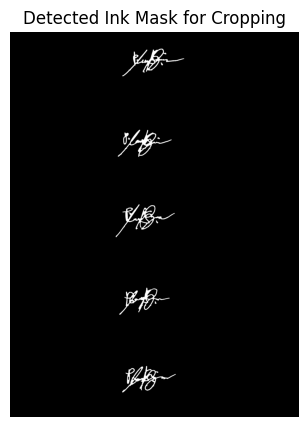

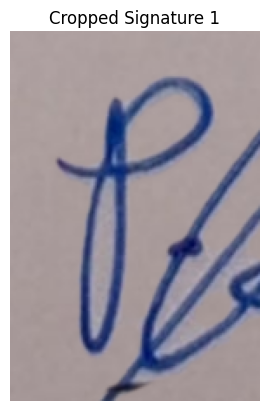

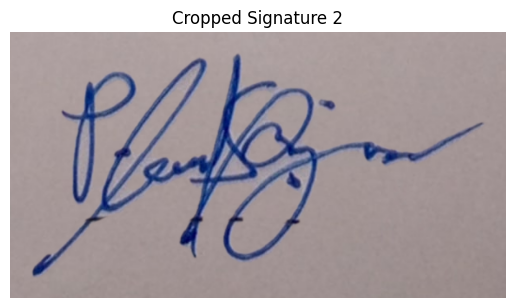

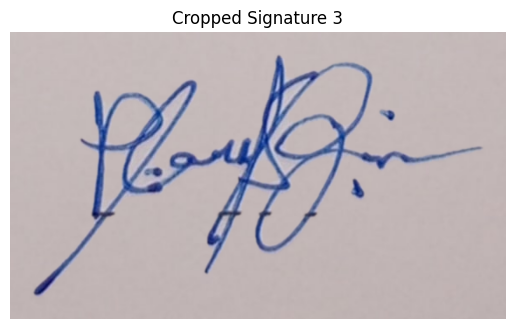

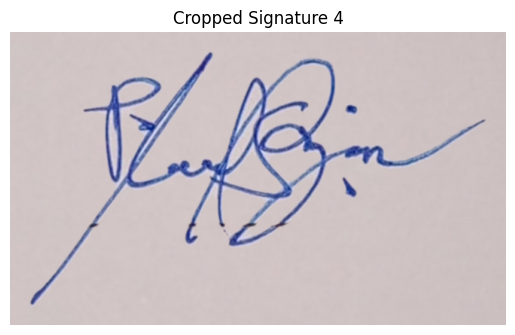

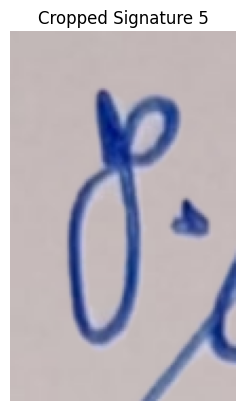

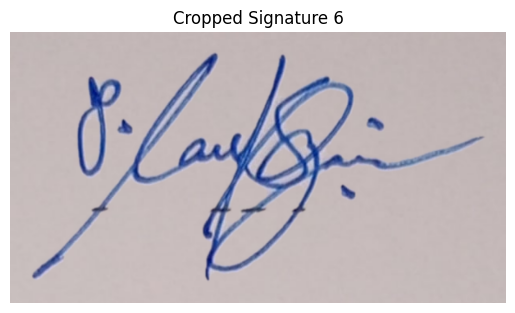

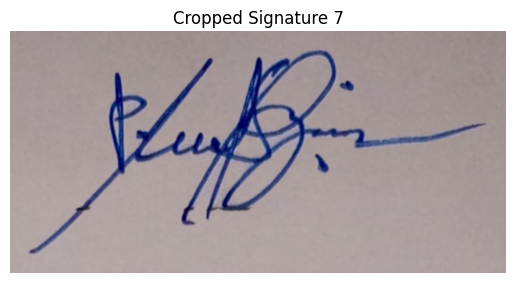

✅ Cropped 7 signatures and saved to 'cropped_signatures'


In [7]:
image_path = "doc_blue_sig3.png"
extract_signature(image_path, crop_signatures)